# 🏛️ Interactive Simulator: Coding Art History

### Welcome, Photo Historians!
In the late 1800s, photographers fought over how a picture should look. 

* **The Pictorialists** wanted their photos to look like soft, dreamy, hand-drawn paintings.
* **The Modernists** wanted their photos to look like razor-sharp, realistic, mechanical records of the real world.

Today, we are going to act as both! We will write code to generate a "raw" photograph, and then use math to process it in two completely different historical styles.

**Teacher Instructions:** Run the cells below to see how algorithms can change the emotional feeling of a photograph.

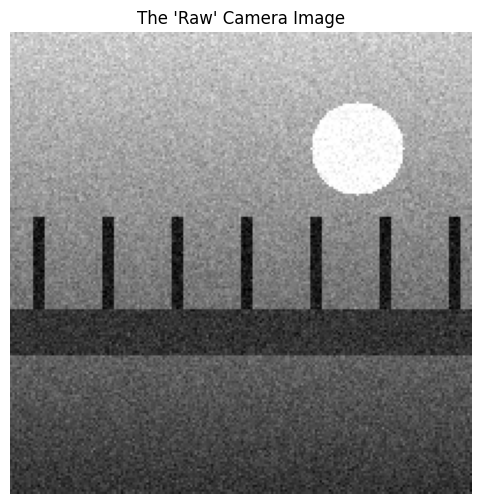

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def create_raw_image():
    """Generates a synthetic 'raw' photograph of a modern bridge."""
    # Create a blank canvas
    img = np.zeros((200, 200))
    
    # Draw the sky (gradient)
    for y in range(200):
        img[y, :] = 0.8 - (y * 0.003)
        
    # Draw a Sun
    y, x = np.ogrid[0:200, 0:200]
    sun_mask = (x - 150)**2 + (y - 50)**2 <= 20**2
    img[sun_mask] = 1.0
    
    # Draw a sharp, geometric bridge (Modernist subject)
    img[120:140, :] = 0.2  # Bridge deck
    for i in range(10, 200, 30):
        img[80:120, i:i+5] = 0.1 # Suspension cables
        
    # Add a little bit of natural camera noise
    noise = np.random.normal(0, 0.05, img.shape)
    img = np.clip(img + noise, 0, 1)
    
    return img

# Generate and show the raw camera file
raw_photo = create_raw_image()

plt.figure(figsize=(6, 6))
plt.imshow(raw_photo, cmap='gray', vmin=0, vmax=1)
plt.title("The 'Raw' Camera Image")
plt.axis('off')
plt.show()

### 🎨 Style 1: The Pictorialist Darkroom (1890s)
The Pictorialists hated sharp lines. They thought the bridge looked too much like an engineering diagram and not enough like "Art."

To make it look like a charcoal drawing or a watercolor painting, they would:
1. Kick the tripod or use vaseline on the lens to **blur** the image.
2. Under-develop the print to **lower the contrast** (no pure blacks or pure whites).
3. Use chemicals like Sepia or Gum Bichromate to give it a **warm, muddy color**.

Let's write the code to simulate this!

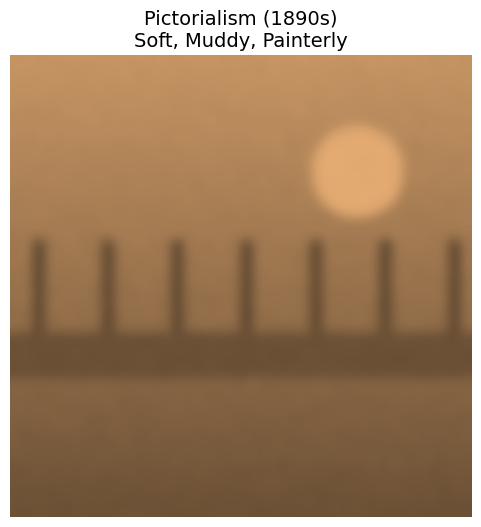

In [2]:
def apply_pictorialism(img):
    """Applies a soft-focus, low-contrast, sepia filter."""
    # 1. Soft Focus (Gaussian Blur)
    blurred_img = gaussian_filter(img, sigma=2.5)
    
    # 2. Low Contrast (Squish the dynamic range so it looks muddy)
    low_contrast = (blurred_img * 0.5) + 0.25
    
    # 3. Add Sepia Tone (Convert grayscale to a warm RGB tint)
    sepia_img = np.zeros((img.shape[0], img.shape[1], 3))
    sepia_img[:,:,0] = low_contrast * 1.2  # Red channel boosted
    sepia_img[:,:,1] = low_contrast * 0.9  # Green channel normal
    sepia_img[:,:,2] = low_contrast * 0.6  # Blue channel reduced (makes it yellow/brown)
    
    # Clip values to keep them valid
    sepia_img = np.clip(sepia_img, 0, 1)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(sepia_img)
    plt.title("Pictorialism (1890s)\nSoft, Muddy, Painterly", fontsize=14)
    plt.axis('off')
    plt.show()

# Run the Pictorialist filter!
apply_pictorialism(raw_photo)

### ⚙️ Style 2: The Modernist Darkroom (Group f/64 - 1930s)
The Modernists (like Ansel Adams and Edward Weston) loved the machine. They wanted the bridge to look powerful, heavy, and engineered. 

To achieve "Straight Photography", they would:
1. Use a tiny aperture (f/64) so the image is **razor sharp**.
2. Develop the print for **maximum contrast** (stark, heavy blacks and blinding whites).
3. Keep it purely **Grayscale**—no romantic, fake colors.

Let's write the code to simulate this!

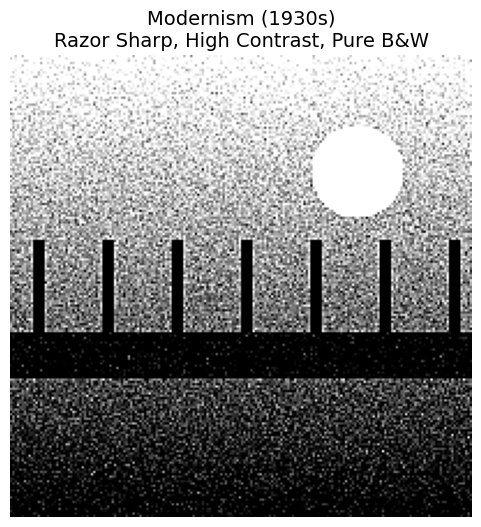

In [3]:
def apply_modernism(img):
    """Applies a high-contrast, razor-sharp grayscale filter."""
    
    # 1. High Contrast (Stretch the dynamic range to the extremes)
    # We use a mathematical curve to make darks darker and lights lighter
    high_contrast = np.clip((img - 0.5) * 2.0 + 0.5, 0, 1)
    
    # 2. Extreme Sharpness (Unsharp Masking algorithm)
    # We subtract a blurred version of the image from the original to enhance edges
    blurred = gaussian_filter(high_contrast, sigma=1)
    sharpened = high_contrast + (high_contrast - blurred) * 1.5
    sharpened = np.clip(sharpened, 0, 1)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(sharpened, cmap='gray', vmin=0, vmax=1)
    plt.title("Modernism (1930s)\nRazor Sharp, High Contrast, Pure B&W", fontsize=14)
    plt.axis('off')
    plt.show()

# Run the Modernist filter!
apply_modernism(raw_photo)

### 📝 The Final Critique
Look at the two generated images. They both come from the exact same raw data, but the math we applied changed their emotion entirely!

* **The Pictorialist Math:** `gaussian_filter` (spreading data out) and reducing the range. 
* **The Modernist Math:** Edge enhancement (sharpening) and expanding the range.

When you take a photo on your phone and apply an "Instagram Filter," you are acting as a digital darkroom technician, deciding whether you want to be a Pictorialist or a Modernist!